<a href="https://colab.research.google.com/github/michaelsteven1299/proyecto_michael-/blob/main/src/03_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Universidad Libre - Seccional Cali<br>Facultad de Ingeniería - Diplomado en Ciencia de Datos<br>(ↄ) Diego Fernando Marin, 2024

# 03_EDA
Plantilla para el desarrollo del proyecto del diplomado de Ciencia de Datos, aplicando buenas prácticas.

---

Este cuaderno se centra en comprender profundamente los datos mediante análisis estadístico y visualización. El EDA nos permite descubrir patrones, relaciones y características importantes en los datos.

**Propósito:** Obtener insights sobre los datos y preparar el terreno para la selección de características relevantes para el modelado.

**Tareas habituales:**
- Análisis univariante de variables
- Análisis de correlaciones
- Visualización de distribuciones
- Detección de patrones y tendencias
- Análisis de series temporales si aplica
- Identificación de relaciones entre variables
- Generación de hipótesis
- Documentación de insights importantes

**Cada sección debe tener**:
- La Pregunta que se realiza sobre los datos
- El código que genera las tablas o los gráficos donde encontramos la respuesta
- El código que da respuesta a dicha pregunta
- La interpretar del resultado
- Las conclusiones

Análisis Exploratorio

IMPORTAMOS LA TABLA DESDE TRUSTED

In [ ]:
import os

try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = "/content/drive/MyDrive/proyecto_oro/"
except ImportError:
    BASE_PATH = "./_ci_cache/"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

CLEAN_PATH = BASE_PATH + "data/clean/"
df = pd.read_csv(CLEAN_PATH + "oro_cop_limpio.csv", index_col='DATE', parse_dates=True)

print(f"Filas: {len(df):,} | Columnas: {len(df.columns)}")
df.head()


In [2]:
df.describe()

,oro_xauusd_Close,usd_cop_Close,oro_cop,dxy_Close,vix_Close,wti_crudo_Close,bono_10y_Close
count,1403.000000,1403.000000,1.403000e+03,1403.000000,1403.000000,1403.000000,1403.000000
mean,233.279109,4032.455780,9.291088e+05,100.797557,19.295011,76.745217,3.473445
std,87.413362,352.596628,3.111196e+05,5.189611,5.116719,13.355510,1.132018
min,151.229996,3121.929932,5.682377e+05,89.440002,11.860000,47.619999,0.917000
25%,170.229996,3792.445068,6.914604e+05,97.814999,15.795000,67.689999,2.842000
50%,185.100006,3973.131592,8.015471e+05,101.470001,18.040001,74.730003,4.002000
75%,272.959991,4206.245117,1.128183e+06,104.380001,21.770000,82.950001,4.295000
max,495.899994,5106.000000,1.821119e+06,114.110001,52.330002,123.699997,4.988000


In [3]:
df['retorno_oro_cop'] = df['oro_cop'].pct_change()
df['retorno_oro_usd'] = df['oro_xauusd_Close'].pct_change()
df['retorno_usd_cop'] = df['usd_cop_Close'].pct_change()
df['retorno_dxy']     = df['dxy_Close'].pct_change()
df['retorno_vix']     = df['vix_Close'].pct_change()
df['retorno_wti']     = df['wti_crudo_Close'].pct_change()
df['retorno_bono_10y']= df['bono_10y_Close'].pct_change()

df[['retorno_oro_cop', 'retorno_usd_cop']].describe()

,retorno_oro_cop,retorno_usd_cop
count,1402.000000,1402.000000
mean,0.000602,-0.000006
std,0.014957,0.009612
min,-0.106736,-0.043794
25%,-0.008554,-0.005865
50%,0.000626,-0.000388
75%,0.009371,0.005519
max,0.067355,0.050369


In [4]:
from matplotlib.ticker import FuncFormatter
from matplotlib.colors import LinearSegmentedColormap

# Paleta de color consistente para todas las graficas de este cuaderno
COLOR_PRINCIPAL = '#2a78d6'   # azul - serie principal / valores positivos
COLOR_MUTED     = '#c3c2b7'   # gris - contexto / no destacado
COLOR_CRITICO   = '#d03b3b'   # rojo - valores negativos / alerta
cmap_div = LinearSegmentedColormap.from_list('oro_diverging', [COLOR_CRITICO, '#f0efec', COLOR_PRINCIPAL])

# Titulo, unidad y si se formatea como moneda (separador de miles) por variable.
# Esto evita el problema de no saber si una grafica esta en dolares, pesos,
# puntos de indice o porcentaje.
VARS_INFO = {
    'oro_xauusd_Close': {'titulo': 'Oro internacional (XAU/USD)',        'unidad': 'USD por onza',             'moneda': True},
    'usd_cop_Close':    {'titulo': 'Tasa de cambio USD/COP',             'unidad': 'COP por USD',              'moneda': True},
    'oro_cop':          {'titulo': 'Oro en pesos colombianos',           'unidad': 'COP por onza',             'moneda': True},
    'dxy_Close':        {'titulo': 'Indice del dolar (DXY)',             'unidad': 'puntos de indice',         'moneda': False},
    'vix_Close':        {'titulo': 'Indice de volatilidad (VIX)',        'unidad': 'puntos de indice',         'moneda': False},
    'wti_crudo_Close':  {'titulo': 'Petroleo WTI',                       'unidad': 'USD por barril',           'moneda': True},
    'bono_10y_Close':   {'titulo': 'Bono del Tesoro EE.UU. a 10 anios',  'unidad': '% de rendimiento anual',   'moneda': False},
}
columnas_mercado = ['oro_xauusd_Close', 'usd_cop_Close', 'oro_cop', 'dxy_Close',
                     'vix_Close', 'wti_crudo_Close', 'bono_10y_Close']


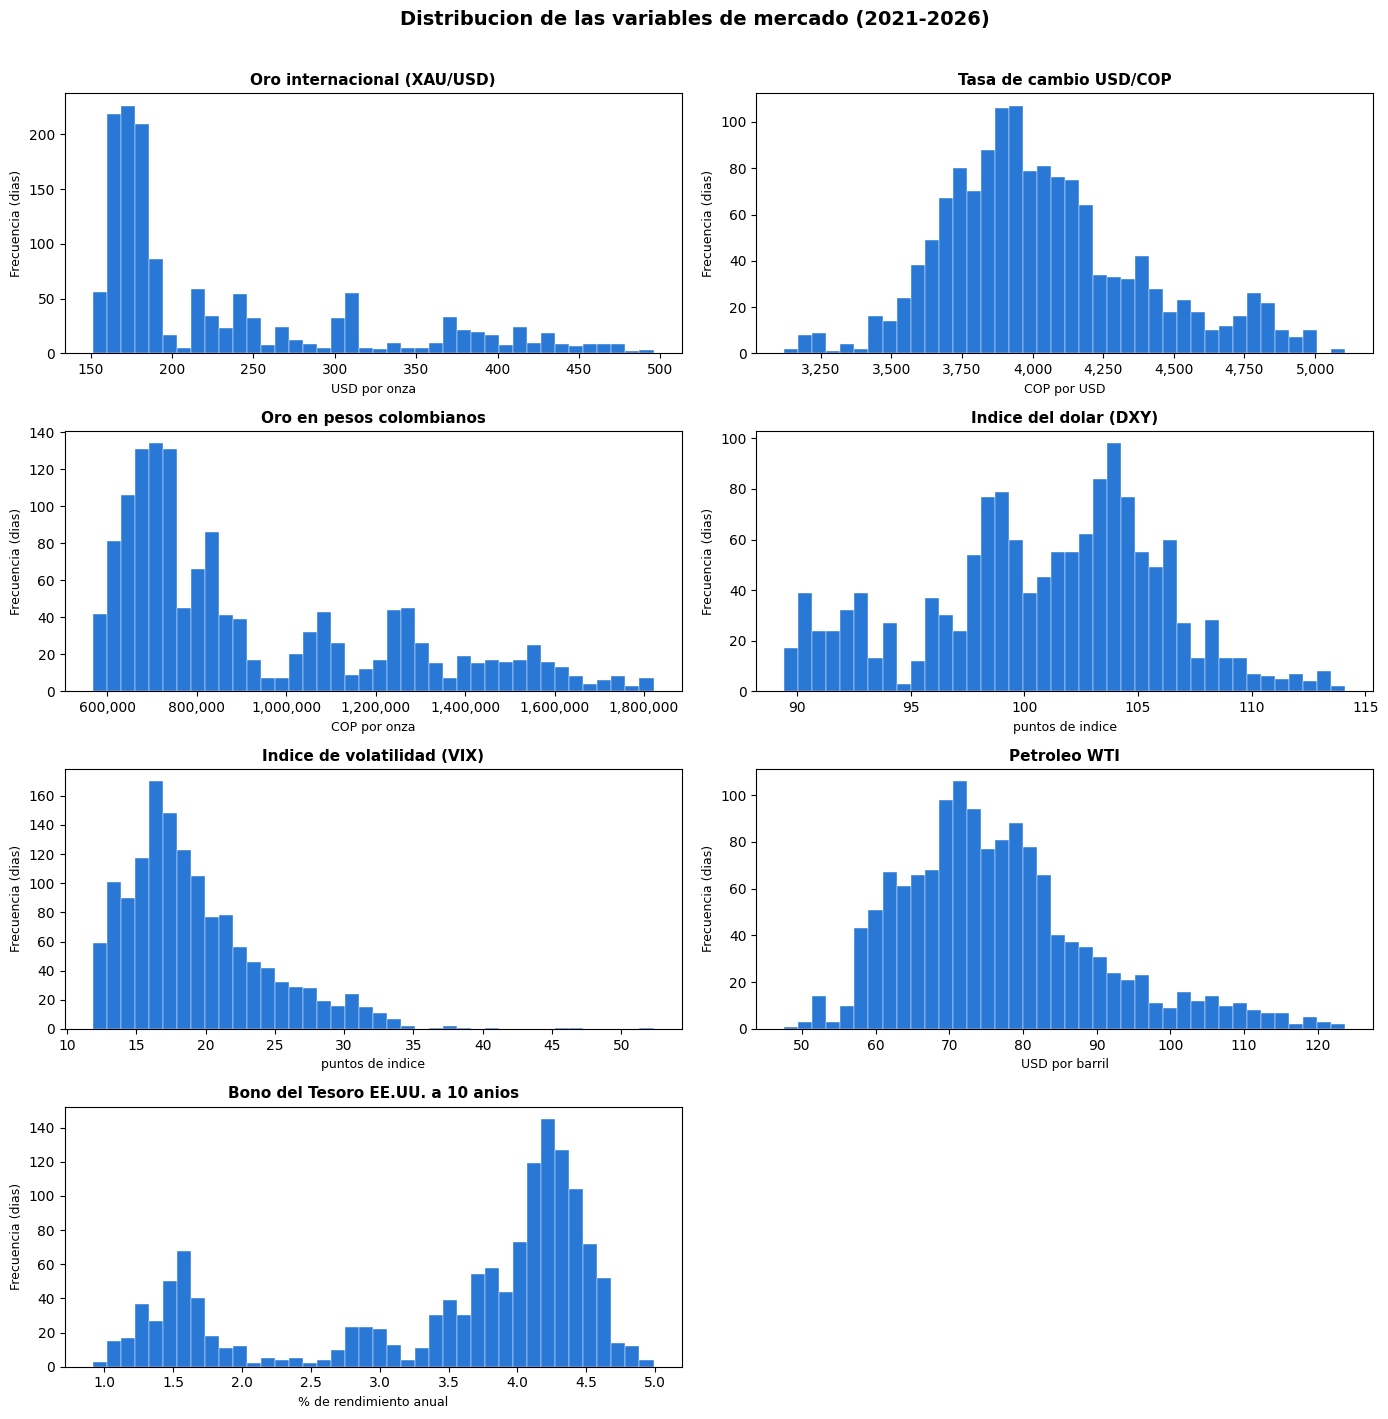

In [5]:
fig, axes = plt.subplots(4, 2, figsize=(14, 14))
axes = axes.flatten()

for ax, col in zip(axes, columnas_mercado):
    info = VARS_INFO[col]
    ax.hist(df[col].dropna(), bins=40, color=COLOR_PRINCIPAL, edgecolor='white', linewidth=0.3)
    ax.set_title(info['titulo'], fontsize=11, fontweight='bold')
    ax.set_xlabel(info['unidad'], fontsize=9)
    ax.set_ylabel('Frecuencia (dias)', fontsize=9)
    if info['moneda']:
        ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))

axes[-1].axis('off')
fig.suptitle('Distribucion de las variables de mercado (2021-2026)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


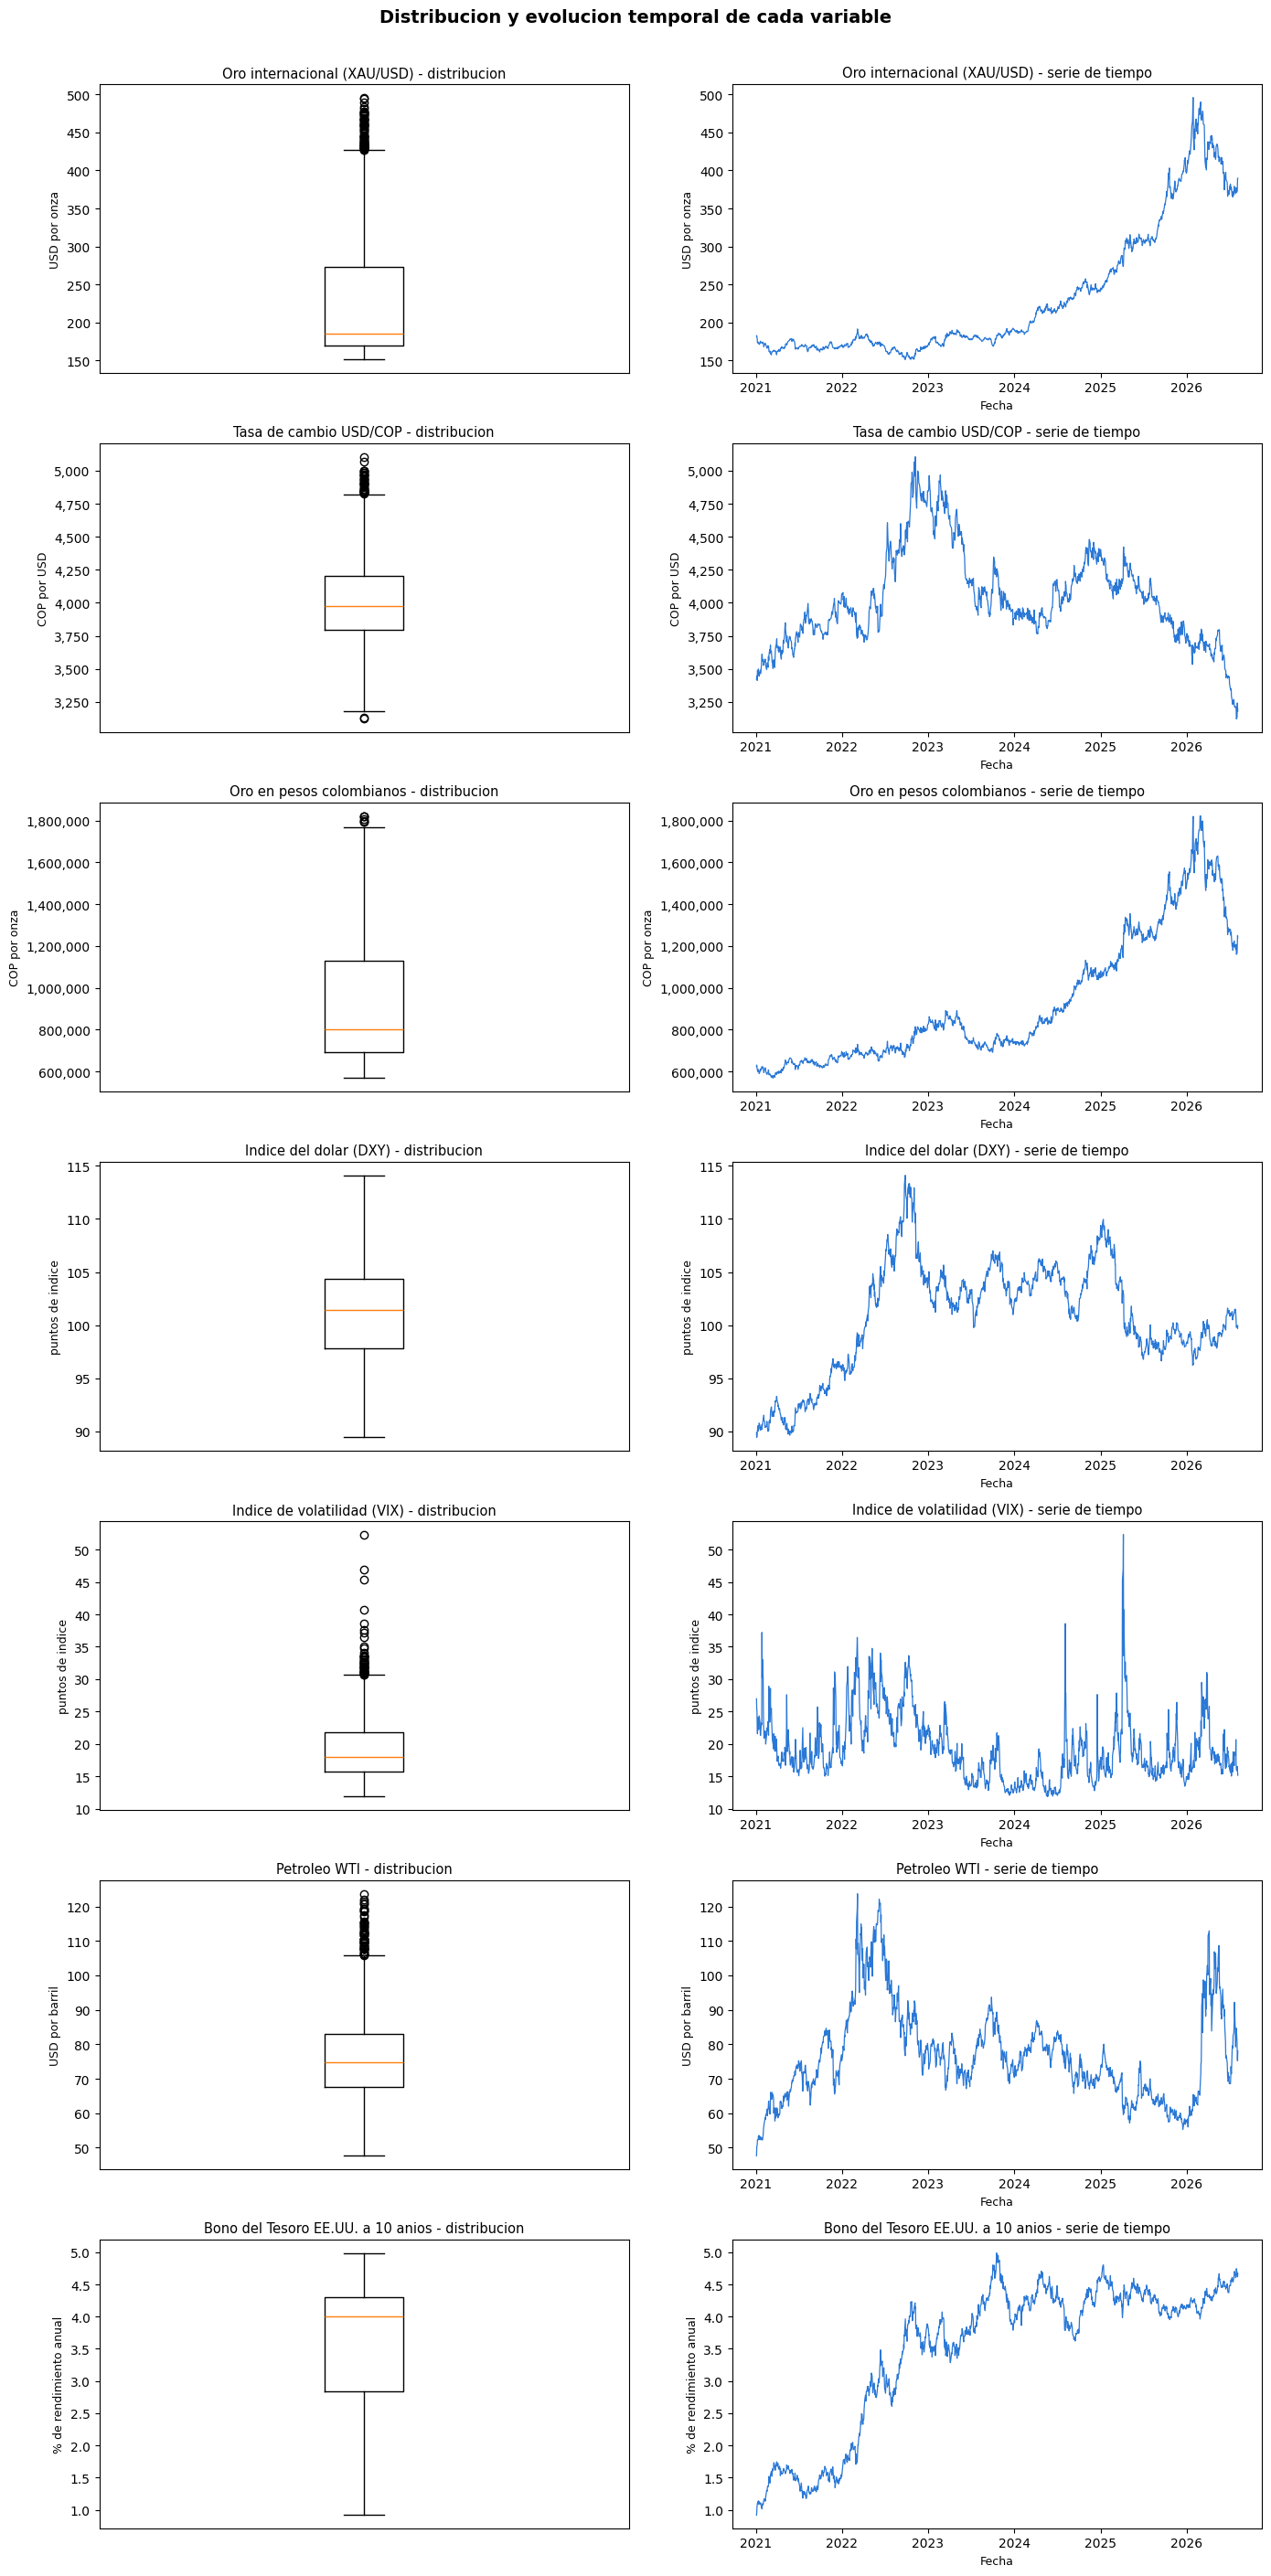

In [6]:
fig, axes = plt.subplots(len(columnas_mercado), 2, figsize=(14, 4 * len(columnas_mercado)))

for i, col in enumerate(columnas_mercado):
    info = VARS_INFO[col]

    axes[i, 0].boxplot(df[col].dropna(), vert=True)
    axes[i, 0].set_title(f"{info['titulo']} - distribucion", fontsize=10.5)
    axes[i, 0].set_ylabel(info['unidad'], fontsize=9)
    axes[i, 0].set_xticks([])
    if info['moneda']:
        axes[i, 0].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))

    axes[i, 1].plot(df.index, df[col], color=COLOR_PRINCIPAL, linewidth=0.9)
    axes[i, 1].set_title(f"{info['titulo']} - serie de tiempo", fontsize=10.5)
    axes[i, 1].set_ylabel(info['unidad'], fontsize=9)
    axes[i, 1].set_xlabel('Fecha', fontsize=9)
    if info['moneda']:
        axes[i, 1].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))

fig.suptitle('Distribucion y evolucion temporal de cada variable', fontsize=14, fontweight='bold', y=1.005)
plt.tight_layout()
plt.show()


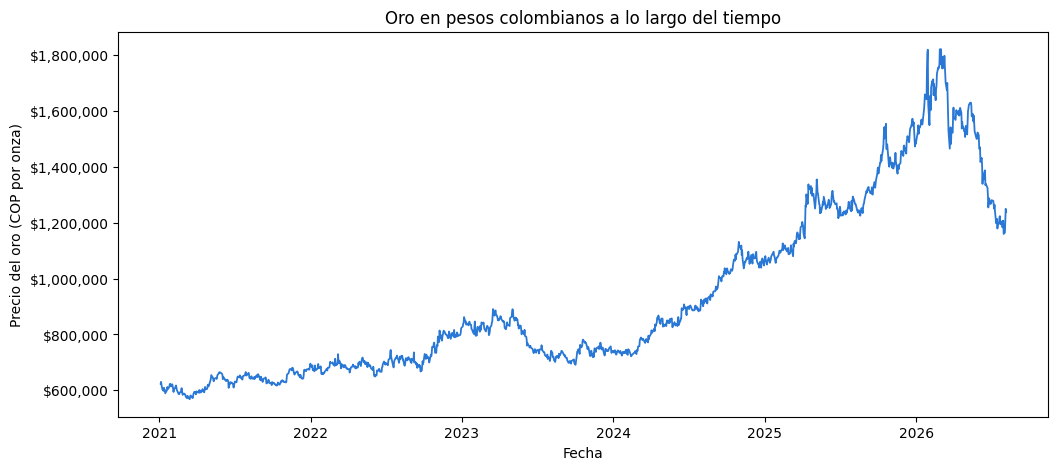

In [7]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['oro_cop'], color=COLOR_PRINCIPAL, linewidth=1.3)
plt.title('Oro en pesos colombianos a lo largo del tiempo')
plt.ylabel('Precio del oro (COP por onza)')
plt.xlabel('Fecha')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.show()


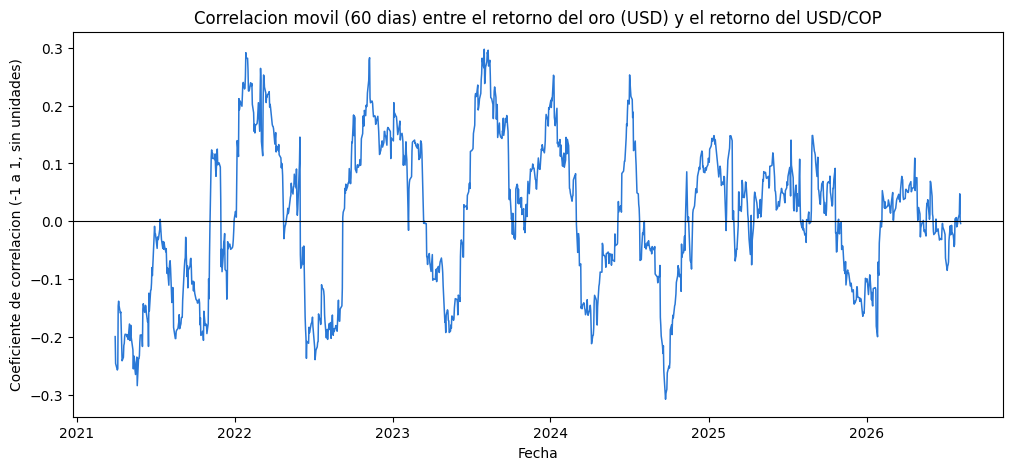

count    1343.000000
mean        0.007778
std         0.126946
min        -0.307437
25%        -0.085104
50%         0.016022
75%         0.100558
max         0.297326
dtype: float64


In [8]:
corr_movil = df['retorno_oro_usd'].rolling(60).corr(df['retorno_usd_cop'])

plt.figure(figsize=(12, 5))
plt.plot(df.index, corr_movil, color=COLOR_PRINCIPAL, linewidth=1.1)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Correlacion movil (60 dias) entre el retorno del oro (USD) y el retorno del USD/COP')
plt.ylabel('Coeficiente de correlacion (-1 a 1, sin unidades)')
plt.xlabel('Fecha')
plt.show()

print(corr_movil.describe())


In [9]:
for lag in range(1, 31):
    df[f'usd_cop_lag_{lag}'] = df['retorno_usd_cop'].shift(lag)

df.filter(like='usd_cop_lag').head()

,usd_cop_lag_1,usd_cop_lag_2,usd_cop_lag_3,usd_cop_lag_4,usd_cop_lag_5,usd_cop_lag_6,usd_cop_lag_7,usd_cop_lag_8,usd_cop_lag_9,usd_cop_lag_10,...,usd_cop_lag_21,usd_cop_lag_22,usd_cop_lag_23,usd_cop_lag_24,usd_cop_lag_25,usd_cop_lag_26,usd_cop_lag_27,usd_cop_lag_28,usd_cop_lag_29,usd_cop_lag_30
DATE,,,,,,,,,,,,,,,,,,,,,
2021-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-06,0.008040,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-07,-0.001595,0.008040,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-08,-0.008555,-0.001595,0.00804,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


5     0.099803
8     0.058720
16   -0.056649
6    -0.055387
23   -0.055314
10    0.053268
4    -0.042578
25   -0.041719
13   -0.037603
29    0.035359
21   -0.029635
2    -0.028363
12   -0.024692
3    -0.024503
18    0.023094
17    0.022538
24   -0.019817
22    0.018753
7    -0.015035
15   -0.013935
30    0.012001
26   -0.009952
19    0.009511
27    0.008593
11    0.007359
1    -0.004967
28    0.001941
14   -0.001795
9     0.001314
20    0.000692
dtype: float64


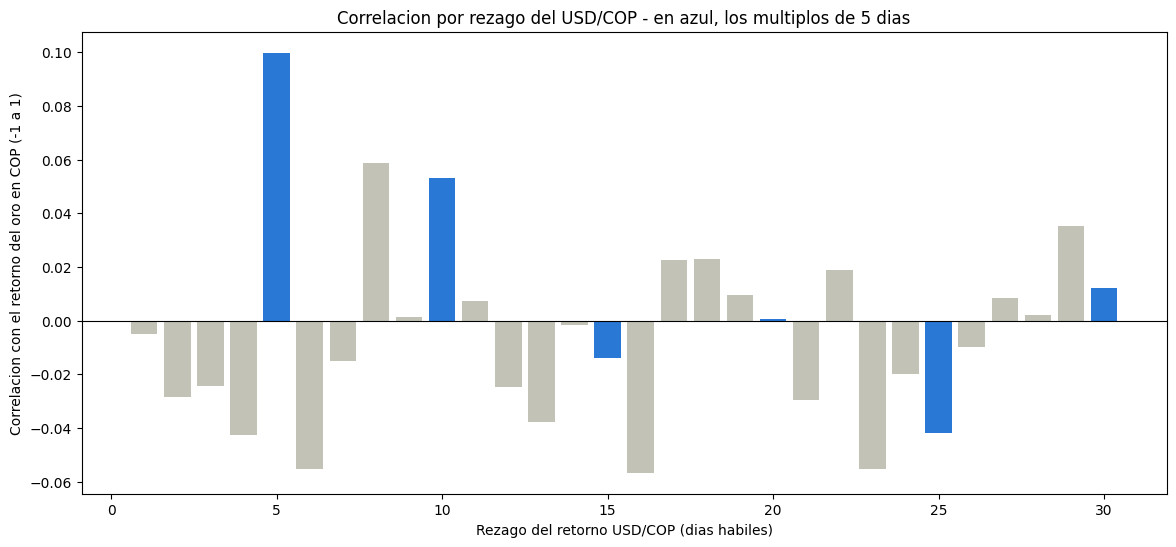

In [10]:
target = df['retorno_oro_cop']
correlaciones = {lag: df[f'usd_cop_lag_{lag}'].corr(target) for lag in range(1, 31)}
corr_lags = pd.Series(correlaciones)

print(corr_lags.sort_values(key=abs, ascending=False))

fig, ax = plt.subplots(figsize=(14, 6))
colores = [COLOR_PRINCIPAL if lag % 5 == 0 else COLOR_MUTED for lag in corr_lags.index]
ax.bar(corr_lags.index, corr_lags.values, color=colores)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Rezago del retorno USD/COP (dias habiles)')
ax.set_ylabel('Correlacion con el retorno del oro en COP (-1 a 1)')
ax.set_title('Correlacion por rezago del USD/COP - en azul, los multiplos de 5 dias')
plt.show()


                mean       std  count
dia_semana                           
Monday     -0.004128  0.009019    259
Tuesday     0.003719  0.011385    291
Wednesday   0.000768  0.008225    289
Thursday   -0.000908  0.008699    282
Friday      0.000046  0.008715    281

F-statistic: 25.6084 | p-valor: 0.0000000000


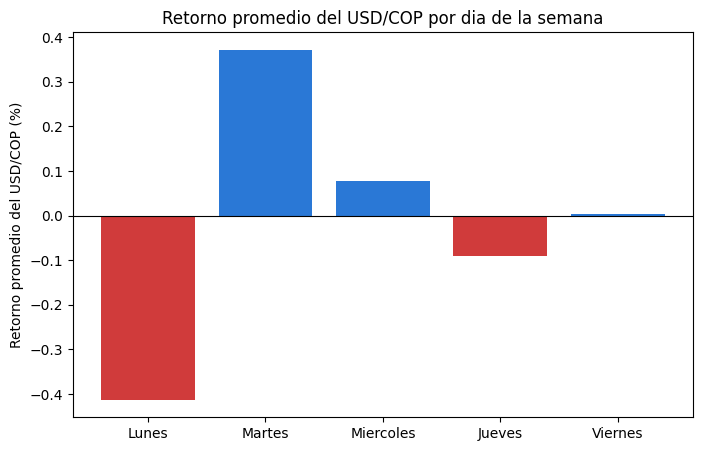

In [11]:
from scipy.stats import f_oneway

df['dia_semana'] = df.index.day_name()
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
df['dia_semana'] = pd.Categorical(df['dia_semana'], categories=orden_dias, ordered=True)

resumen_dia = df.groupby('dia_semana', observed=True)['retorno_usd_cop'].agg(['mean', 'std', 'count'])
print(resumen_dia)

grupos = [df[df['dia_semana'] == d]['retorno_usd_cop'].dropna() for d in orden_dias]
f_stat, p_valor = f_oneway(*grupos)
print(f"\nF-statistic: {f_stat:.4f} | p-valor: {p_valor:.10f}")

medias_pct = df.groupby('dia_semana', observed=True)['retorno_usd_cop'].mean() * 100
colores_dia = [COLOR_PRINCIPAL if v >= 0 else COLOR_CRITICO for v in medias_pct.values]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(['Lunes', 'Martes', 'Miercoles', 'Jueves', 'Viernes'], medias_pct.values, color=colores_dia)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Retorno promedio del USD/COP (%)')
ax.set_title('Retorno promedio del USD/COP por dia de la semana')
plt.show()


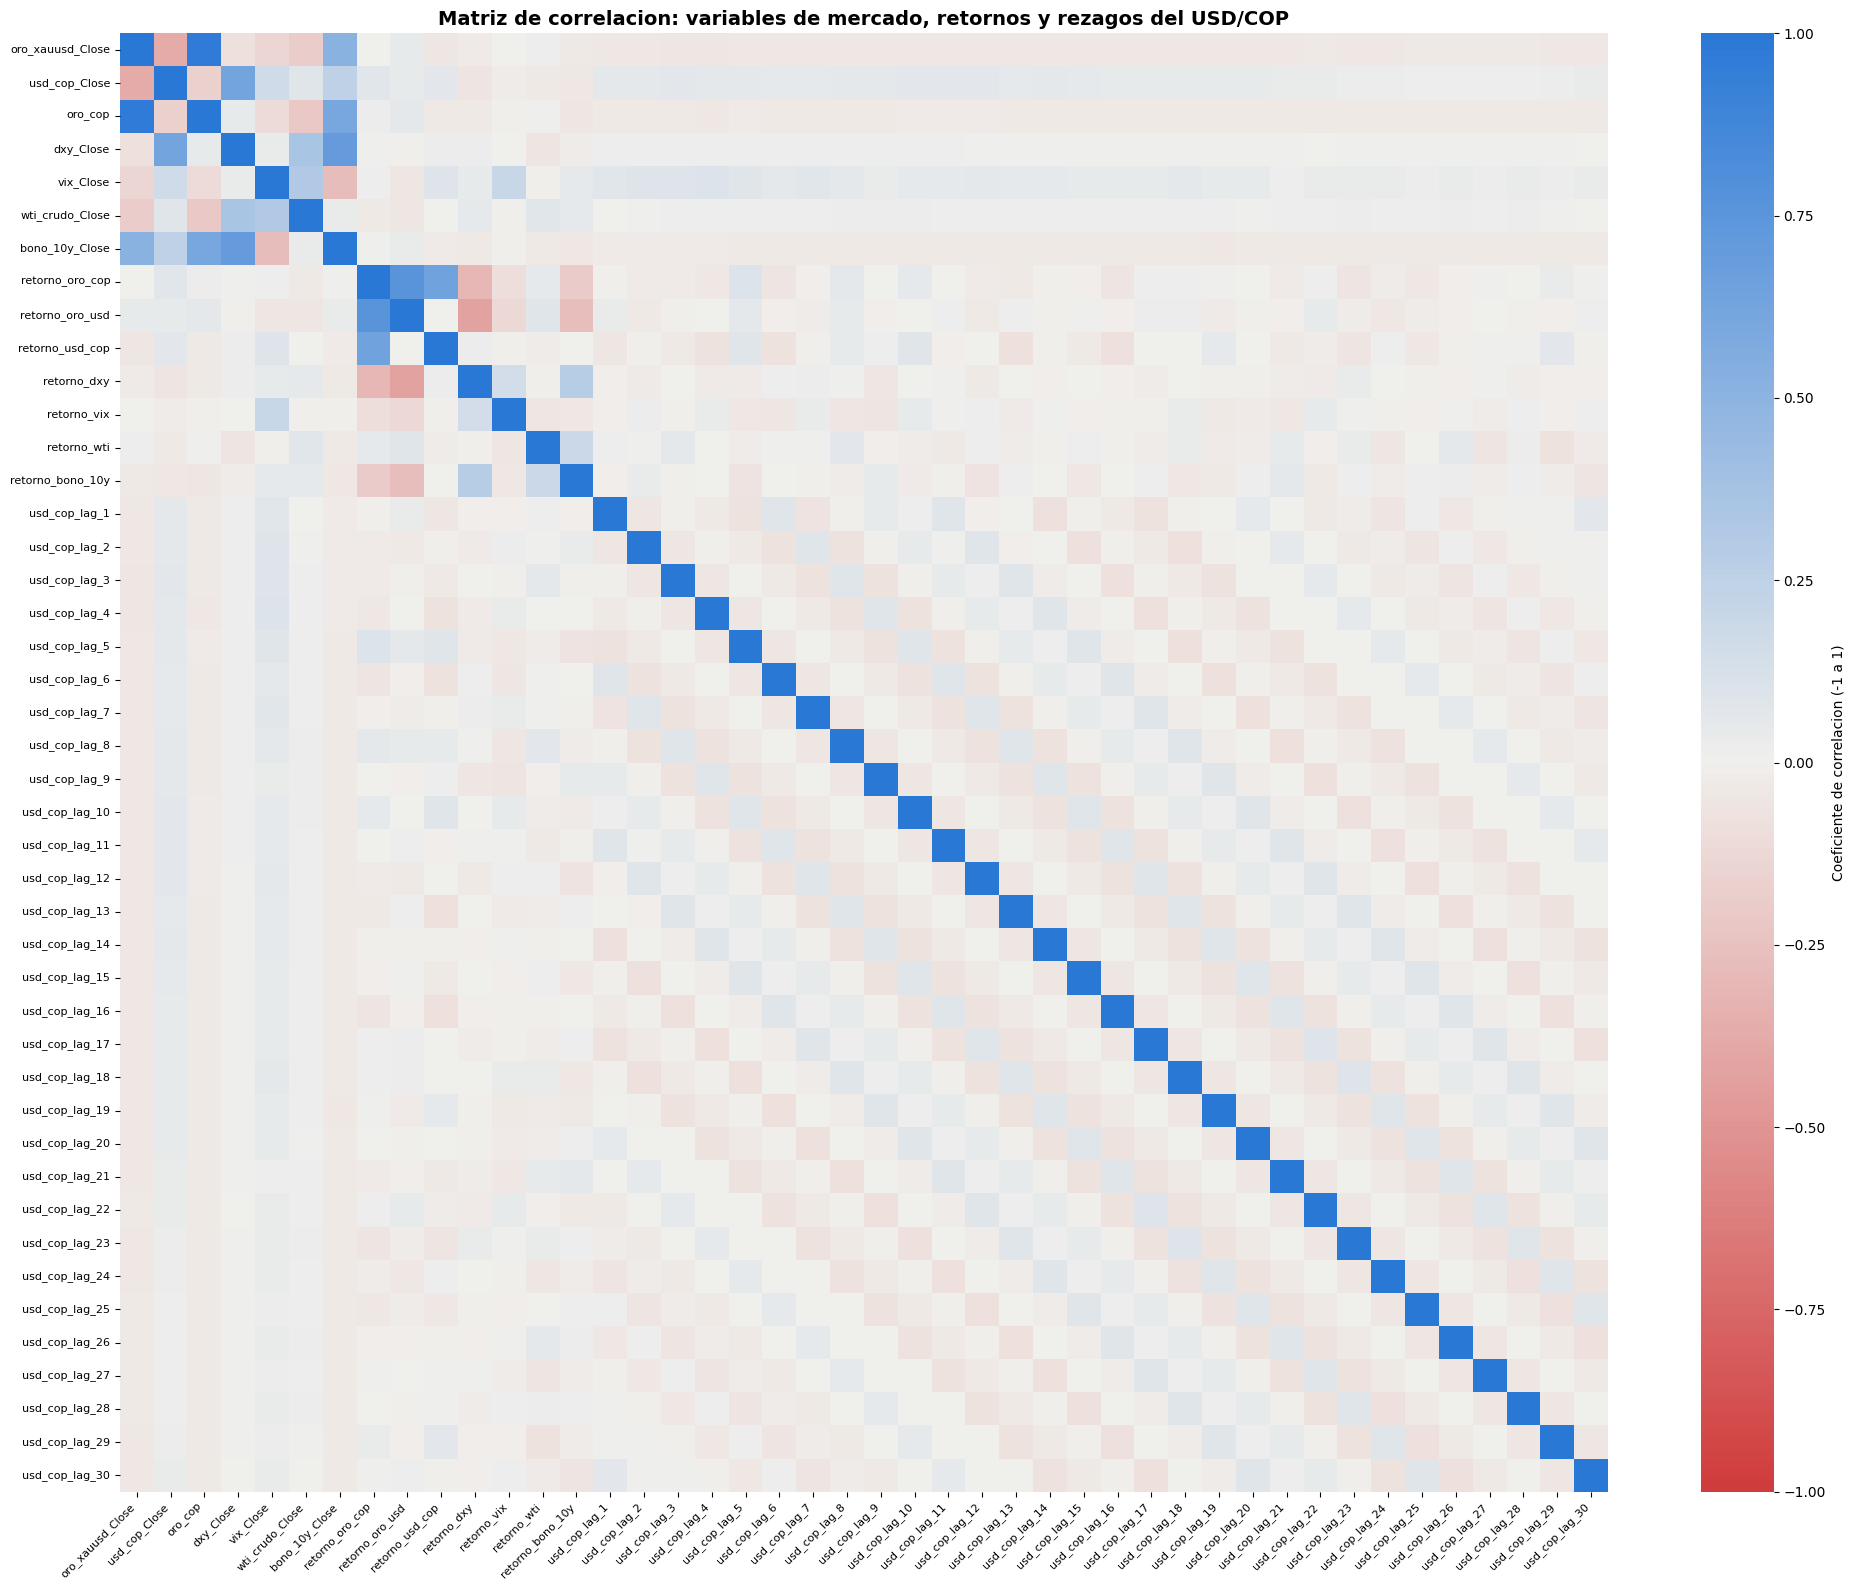

In [12]:
plt.figure(figsize=(20, 16))
sns.heatmap(df.corr(numeric_only=True), cmap=cmap_div, center=0, vmin=-1, vmax=1,
            cbar_kws={'label': 'Coeficiente de correlacion (-1 a 1)'})
plt.title('Matriz de correlacion: variables de mercado, retornos y rezagos del USD/COP', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()


In [13]:
otras = ['retorno_dxy', 'retorno_vix', 'retorno_wti', 'retorno_bono_10y']
correlacion_otras = df[otras].corrwith(df['retorno_oro_cop'])
print("Correlación de retornos (análisis exploratorio complementario):")
print(correlacion_otras.sort_values(key=abs, ascending=False))

Correlación de retornos (análisis exploratorio complementario):
retorno_dxy        -0.308339
retorno_bono_10y   -0.202717
retorno_vix        -0.094534
retorno_wti         0.053500
dtype: float64


In [14]:
# Reconstruir con ffill(limit=3), igual al pipeline original que generó trusted
df_test = df[['oro_xauusd_Close', 'usd_cop_Close']].copy()
df_test = df_test.asfreq('D')  # aseguramos frecuencia diaria para que ffill tenga huecos que rellenar
df_test = df_test.ffill(limit=3)
df_test = df_test[df_test.index.dayofweek < 5]

df_test['oro_cop'] = df_test['oro_xauusd_Close'] * df_test['usd_cop_Close']
df_test['retorno_oro_cop'] = df_test['oro_cop'].pct_change()
df_test['retorno_usd_cop'] = df_test['usd_cop_Close'].pct_change()

for lag in range(1, 31):
    df_test[f'usd_cop_lag_{lag}'] = df_test['retorno_usd_cop'].shift(lag)

target = df_test['retorno_oro_cop']
correlaciones_test = {lag: df_test[f'usd_cop_lag_{lag}'].corr(target) for lag in range(1, 31)}
corr_test = pd.Series(correlaciones_test)

print(f"Filas con ffill: {len(df_test)}")
print(corr_test.sort_values(key=abs, ascending=False))

Filas con ffill: 1459
5     0.128066
30    0.113439
20    0.112518
10    0.105665
26   -0.077646
21   -0.070610
16   -0.067513
4    -0.060358
8     0.060294
12   -0.055771
19   -0.045449
6    -0.044286
7    -0.043603
15    0.035121
9    -0.034802
24   -0.033366
2    -0.033310
18    0.032640
14   -0.032547
17   -0.027917
3    -0.020853
27   -0.020746
23   -0.019503
22    0.018540
28    0.010001
25   -0.007357
13    0.007022
11    0.006239
1    -0.005684
29   -0.003225
dtype: float64


/tmp/ipykernel_590/2205600088.py:8: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_test['retorno_oro_cop'] = df_test['oro_cop'].pct_change()
/tmp/ipykernel_590/2205600088.py:9: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_test['retorno_usd_cop'] = df_test['usd_cop_Close'].pct_change()


In [15]:
# Con base en la Celda 9 (sin ffill, tu resultado más riguroso):
# lag 5, 8, 10 (positivos) y lag 16 (negativo) fueron los más destacados
lags_seleccionados = [5, 8, 10, 16]

cols_seleccionadas = [f'usd_cop_lag_{lag}' for lag in lags_seleccionados]
df[cols_seleccionadas].head()

,usd_cop_lag_5,usd_cop_lag_8,usd_cop_lag_10,usd_cop_lag_16
DATE,,,,
2021-01-04,NaN,NaN,NaN,NaN
2021-01-05,NaN,NaN,NaN,NaN
2021-01-06,NaN,NaN,NaN,NaN
2021-01-07,NaN,NaN,NaN,NaN
2021-01-08,NaN,NaN,NaN,NaN


In [16]:
df['dia_semana_num'] = df.index.dayofweek  # 0=lunes, 4=viernes
dummies_dia = pd.get_dummies(df['dia_semana_num'], prefix='dia', drop_first=True)
df = pd.concat([df, dummies_dia], axis=1)

print(dummies_dia.columns.tolist())

['dia_1', 'dia_2', 'dia_3', 'dia_4']


In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

features = cols_seleccionadas + dummies_dia.columns.tolist()
df_modelo = df.dropna(subset=features + ['retorno_oro_cop'])

X = df_modelo[features]
y = df_modelo['retorno_oro_cop']

split = int(len(df_modelo) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

modelo = LinearRegression()
modelo.fit(X_train, y_train)
pred = modelo.predict(X_test)

rmse_modelo = np.sqrt(mean_squared_error(y_test, pred))
rmse_persistencia = np.sqrt(mean_squared_error(y_test, np.zeros(len(y_test))))

print(f"RMSE Modelo reducido (4 lags + día semana): {rmse_modelo:.5f}")
print(f"RMSE referencia (retorno = 0):                {rmse_persistencia:.5f}")
print(f"\n¿Mejoró? {'SÍ' if rmse_modelo < rmse_persistencia else 'NO'}")

RMSE Modelo reducido (4 lags + día semana): 0.01928
RMSE referencia (retorno = 0):                0.01963

¿Mejoró? SÍ


In [18]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=6)
rmses_modelo = []
rmses_referencia = []

for train_idx, test_idx in tscv.split(X):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    m = LinearRegression()
    m.fit(X_tr, y_tr)
    pred = m.predict(X_te)

    rmses_modelo.append(np.sqrt(mean_squared_error(y_te, pred)))
    rmses_referencia.append(np.sqrt(mean_squared_error(y_te, np.zeros(len(y_te)))))

print("RMSE por ventana (modelo reducido):", [round(r, 5) for r in rmses_modelo])
print("RMSE por ventana (referencia):      ", [round(r, 5) for r in rmses_referencia])
print(f"\nVentanas donde el modelo ganó: {sum(m < r for m, r in zip(rmses_modelo, rmses_referencia))} de {len(rmses_modelo)}")

RMSE por ventana (modelo reducido): [np.float64(0.0132), np.float64(0.01611), np.float64(0.01167), np.float64(0.01313), np.float64(0.01531), np.float64(0.02081)]
RMSE por ventana (referencia):       [np.float64(0.01312), np.float64(0.01619), np.float64(0.01196), np.float64(0.01347), np.float64(0.01555), np.float64(0.02134)]

Ventanas donde el modelo ganó: 5 de 6


In [19]:
df['retorno_dxy_lag1']      = df['retorno_dxy'].shift(1)
df['retorno_vix_lag1']      = df['retorno_vix'].shift(1)
df['retorno_wti_lag1']      = df['retorno_wti'].shift(1)
df['retorno_bono_10y_lag1'] = df['retorno_bono_10y'].shift(1)

df[['retorno_dxy_lag1', 'retorno_vix_lag1', 'retorno_wti_lag1', 'retorno_bono_10y_lag1']].describe()

,retorno_dxy_lag1,retorno_vix_lag1,retorno_wti_lag1,retorno_bono_10y_lag1
count,1401.000000,1401.000000,1401.000000,1401.000000
mean,0.000084,0.002720,0.000654,0.001373
std,0.004372,0.081936,0.025468,0.020944
min,-0.021167,-0.357539,-0.164143,-0.099088
25%,-0.002435,-0.041280,-0.013751,-0.010468
50%,0.000190,-0.007500,0.001853,0.000796
75%,0.002688,0.036395,0.015134,0.012335
max,0.016525,0.740391,0.122084,0.092873


In [20]:
nuevas_vars = ['retorno_dxy_lag1', 'retorno_vix_lag1', 'retorno_wti_lag1', 'retorno_bono_10y_lag1']
corr_nuevas = df[nuevas_vars].corrwith(df['retorno_oro_cop'])
print(corr_nuevas.sort_values(key=abs, ascending=False))

retorno_dxy_lag1         0.197513
retorno_vix_lag1         0.109446
retorno_wti_lag1        -0.085647
retorno_bono_10y_lag1    0.074124
dtype: float64


In [21]:
features_ampliado = cols_seleccionadas + dummies_dia.columns.tolist() + nuevas_vars
df_modelo2 = df.dropna(subset=features_ampliado + ['retorno_oro_cop'])

X2 = df_modelo2[features_ampliado]
y2 = df_modelo2['retorno_oro_cop']

tscv = TimeSeriesSplit(n_splits=6)
rmses_ampliado = []
rmses_ref2 = []

for train_idx, test_idx in tscv.split(X2):
    X_tr, X_te = X2.iloc[train_idx], X2.iloc[test_idx]
    y_tr, y_te = y2.iloc[train_idx], y2.iloc[test_idx]

    m = LinearRegression()
    m.fit(X_tr, y_tr)
    pred = m.predict(X_te)

    rmses_ampliado.append(np.sqrt(mean_squared_error(y_te, pred)))
    rmses_ref2.append(np.sqrt(mean_squared_error(y_te, np.zeros(len(y_te)))))

print("RMSE modelo ampliado (8 vars):", [round(r, 5) for r in rmses_ampliado])
print("RMSE referencia:               ", [round(r, 5) for r in rmses_ref2])
print(f"\nVentanas donde el modelo ampliado ganó: {sum(m < r for m, r in zip(rmses_ampliado, rmses_ref2))} de {len(rmses_ampliado)}")

RMSE modelo ampliado (8 vars): [np.float64(0.01321), np.float64(0.01541), np.float64(0.01113), np.float64(0.01238), np.float64(0.01504), np.float64(0.02084)]
RMSE referencia:                [np.float64(0.01312), np.float64(0.01619), np.float64(0.01196), np.float64(0.01347), np.float64(0.01555), np.float64(0.02134)]

Ventanas donde el modelo ampliado ganó: 5 de 6


In [22]:
print("Comparación directa por ventana:")
print(f"{'Ventana':<10}{'Reducido (4)':<15}{'Ampliado (8)':<15}{'Referencia':<12}")
for i in range(6):
    print(f"{i+1:<10}{rmses_modelo[i]:<15.5f}{rmses_ampliado[i]:<15.5f}{rmses_referencia[i]:<12.5f}")

Comparación directa por ventana:
Ventana   Reducido (4)   Ampliado (8)   Referencia  
1         0.01320        0.01321        0.01312     
2         0.01611        0.01541        0.01619     
3         0.01167        0.01113        0.01196     
4         0.01313        0.01238        0.01347     
5         0.01531        0.01504        0.01555     
6         0.02081        0.02084        0.02134     


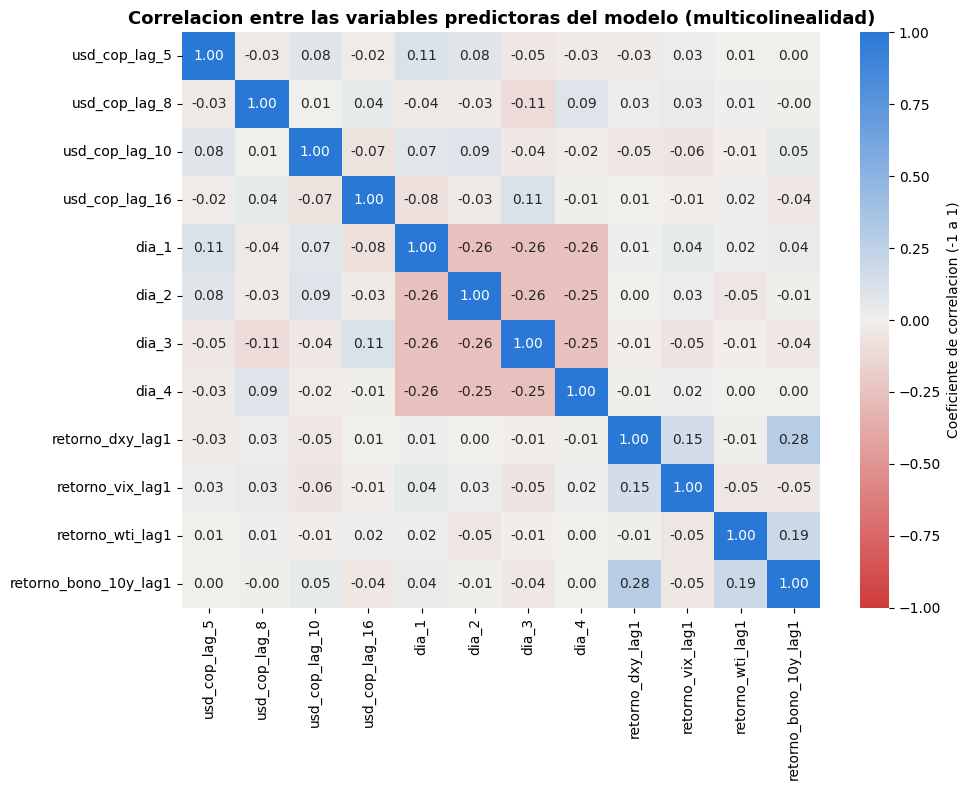

In [23]:
features_ampliado = cols_seleccionadas + dummies_dia.columns.tolist() + nuevas_vars

matriz_features = df[features_ampliado].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_features, cmap=cmap_div, center=0, vmin=-1, vmax=1, annot=True, fmt='.2f',
            cbar_kws={'label': 'Coeficiente de correlacion (-1 a 1)'})
plt.title('Correlacion entre las variables predictoras del modelo (multicolinealidad)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [24]:
# La pregunta clave: ¿el retorno de usd_cop y el retorno de dxy se mueven parecido?
corr_dxy_usdcop = df['retorno_usd_cop'].corr(df['retorno_dxy'])
print(f"Correlación entre retorno_usd_cop y retorno_dxy (mismo día): {corr_dxy_usdcop:.4f}")

# Y entre sus versiones rezagadas usadas en el modelo
corr_lags = df['usd_cop_lag_5'].corr(df['retorno_dxy_lag1'])
print(f"Correlación entre usd_cop_lag_5 y retorno_dxy_lag1: {corr_lags:.4f}")

Correlación entre retorno_usd_cop y retorno_dxy (mismo día): 0.0294
Correlación entre usd_cop_lag_5 y retorno_dxy_lag1: -0.0285


In [25]:
UMBRAL = 0.8

pares_problematicos = []
for i, var1 in enumerate(features_ampliado):
    for var2 in features_ampliado[i+1:]:
        corr = df[var1].corr(df[var2])
        if abs(corr) > UMBRAL:
            pares_problematicos.append((var1, var2, corr))

if pares_problematicos:
    print("⚠ Pares con posible multicolinealidad (>0.8):")
    for v1, v2, c in pares_problematicos:
        print(f"  {v1} - {v2}: {c:.3f}")
else:
    print("✓ Ningún par de variables supera el umbral de 0.8 — no hay multicolinealidad severa")

✓ Ningún par de variables supera el umbral de 0.8 — no hay multicolinealidad severa
